<a id="inicio"></a>

# Nobel Prize Data Lake — ETL Orchestration

## Objective

Build a serverless data lake pipeline that ingests Nobel Prize data from a public API, lands it in S3, transforms it through bronze and silver layers via AWS Lambda, and orchestrates the whole flow with Prefect.

## Methodology

- **Data Lake architecture**: Three-tier S3 layout (`raw` / `bronze` / `silver`)
- **Extraction**: Two AWS Lambda functions — one fetches Nobel Prize records by category/year, another fetches laureate profiles by ID
- **Bronze ETL**: Cleans, joins, and restructures the raw Parquet files into a unified laureate-level table
- **Silver ETL**: Engineers business-ready features (fractional portion parsing, per-laureate real prize amounts)
- **Orchestration**: A Prefect flow runs on a yearly schedule, invoking the Lambdas with year-specific parameters and mapping over the dynamic list of laureate IDs
- **Backfill**: Bulk-load 1901–2019 historical data, then simulate yearly runs from 2021 onward
- **Analytics**: Answer business questions against the final silver table

## Source datasets

- **Live API**: [Nobel Prize API](https://www.nobelprize.org/about/developer-zone-2/) — documented on [SwaggerHub](https://app.swaggerhub.com/apis/NobelMedia/NobelMasterData/2.1)
- **Historical backfill**: `nobelPrizes-1901-2019.parquet` + `laureates-1901-2019.parquet` (under `data/`)

<div class="alert alert-block alert-info">

### ℹ️ Note on cell outputs

The cell outputs visible in this notebook were captured during the **original run** and are shown here as a visual reference for portfolio review. Some artifacts may still appear in Spanish because the outputs predate the English code translation.

**To re-run locally:**

1. This notebook was designed for AWS Academy + AWS Lambda execution. Local runs depend on:
   - An AWS account with S3 access and Lambda deployment permissions
   - An S3 bucket to act as the data lake (with `raw/`, `bronze/`, `silver/` prefixes)
   - The `AWSSDKPandas-Python312` layer attached to each Lambda (or equivalent pyarrow/awswrangler runtime)
2. Install the Python dependencies listed in `requirements_lambda.txt`:
   - `pandas==2.2.3`, `pyarrow==18.1.0`, `requests==2.32.0`, `awswrangler==3.11.0`
3. Deploy the two Lambdas (`extractNobelPrizes`, `extractLaureate`) and the two ETL Lambdas (`bronze_laureates`, `silver_laureates`) per the task descriptions below.
4. Install Prefect (`pip install prefect`) and run the orchestration flow.
5. For local analytics on the silver output, the `data/laureates-1901-2019.parquet` and `data/nobelPrizes-1901-2019.parquet` files bundled in this repo are sufficient to reproduce the analysis without AWS.

</div>

---

## Nobel Prize

This project works with Nobel Prize data — the annual awards ceremonies and the laureates who receive them. We use the [Nobel Prize API](https://www.nobelprize.org/about/developer-zone-2/), documented in OpenAPI format on [SwaggerHub](https://app.swaggerhub.com/apis/NobelMedia/NobelMasterData/2.1).

We build a data lake on **AWS S3**, implement the ETL steps as **AWS Lambda** functions, and orchestrate them with **Prefect** (running the flow locally).

### Workflow description

Nobel Prizes are awarded annually (with occasional gaps — e.g. during World War II). We automate yearly extraction, scheduled to run **every January 1st**, with the following steps:

- Pull the previous year's data for all six categories (`che`, `eco`, `lit`, `pea`, `phy`, `med`)
- Land the raw Parquet files in the data lake under the `raw` prefix
- Run the Bronze and Silver ETLs

Finally, we use this notebook to query the generated tables and answer a handful of **analytics questions**.

### AWS-provided Lambda layer

Throughout this project we deploy AWS Lambda functions that need access to several Python packages (pandas, pyarrow, requests, awswrangler). Instead of packaging them ourselves, we attach the AWS-provided Lambda layer `AWSSDKPandas-Python312` (version 16, Python 3.12), which ships:

```
pandas==2.2.3
pyarrow==18.1.0
requests==2.32.0
awswrangler==3.11.0
```

For local development, create a virtual environment pinned to the same versions (listed in `requirements_lambda.txt`) so code behaves identically in Lambda and locally.

In [1]:
from dotenv import load_dotenv
load_dotenv()




True

In [2]:
import boto3

s3 = boto3.client("s3")
response = s3.list_buckets()
buckets = [b["Name"] for b in response["Buckets"]]
print("Buckets en mi cuenta:", buckets)


<bucket list redacted — see local AWS console>


## Task 1: Create the S3 bucket (our data lake)

Create an S3 bucket in your AWS Academy account with three prefixes:

- **`raw/`** — raw data extracted from the API
- **`bronze/`** — joined tables with renamed columns and cast types
- **`silver/`** — high-level analytics-ready tables

## Task 2: Extraction Lambdas

The extraction functions need to pull `nobelPrizes` and `laureates` data. Specifically:

1. `http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}` — all Nobel Prizes for one category and year
2. `http://api.nobelprize.org/2.1/laureate/{laureateID}` — one laureate's record

Data is stored in the data lake as Parquet (efficient for batch reads via `pd.read_parquet` and supports compaction later). However, Parquet's Python library doesn't support all nested structures present in these API responses — so rather than storing the raw JSON directly, we apply light structural flattening before writing. In a more mature pipeline, we'd land the raw JSON as-is in `raw/` and have a separate Lambda produce a `raw_processed/` layer that matches our current `raw/` output.

**Lambda configuration** for every function below:
- Architecture: `x86_64`
- Runtime: Python 3.12
- IAM role: `LabRole` (the existing AWS Academy role)
- Timeout: 1 minute
- Memory: 2048 MB

### Task 3.1: `extractNobelPrizes` Lambda

This function receives a `category` and `year` in the event payload, calls `http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}`, and constructs a single-row pandas DataFrame with these columns:

- **`awardYear`** — the `awardYear` field; NA if missing
- **`category`** — the `en` field under `category`; NA if missing
- **`categoryFullName`** — the `en` field under `categoryFullName`; NA if missing
- **`dateAwarded`** — the `dateAwarded` field; NA if missing
- **`prizeAmount`** — the `prizeAmount` field; NA if missing
- **`prizeAmountAdjusted`** — the `prizeAmountAdjusted` field; NA if missing
- **`laureates_id`** — a list of laureate IDs (the `id` field of every `laureates` entry)
- **`laureates_portion`** — a list of the `portion` field of every `laureates` entry

The DataFrame is written to S3 at `raw/nobelPrizes/{category}-{year}.parquet`.

The function must also **return a list of the laureate IDs** involved so downstream Lambdas can fetch their profiles.

Test with any of the six category codes — `che`, `eco`, `lit`, `pea`, `phy`, `med` — and any year (e.g. 2010).

In [ ]:
import os
import json
import requests
import pandas as pd
import awswrangler as wr

def lambda_handler(event, context):

    category = event["category"]
    year = event["year"]


    url = f"http://api.nobelprize.org/2.1/nobelPrize/{category}/{year}"
    resp = requests.get(url)
    data = resp.json()


    if isinstance(data, dict):
        nobel_data = data.get("nobelPrizes", [])
    elif isinstance(data, list):
        nobel_data = data
    else:
        nobel_data = []

    if not nobel_data:
        return {
            "message": "No prizes found for this category/year",
            "laureates_id": []
        }

    prize = nobel_data[0]

 
    awardYear = prize.get("awardYear", None)
    category_en = prize.get("category", {}).get("en", None)
    categoryFullName_en = prize.get("categoryFullName", {}).get("en", None)
    dateAwarded = prize.get("dateAwarded", None)
    prizeAmount = prize.get("prizeAmount", None)
    prizeAmountAdjusted = prize.get("prizeAmountAdjusted", None)


    laureates = prize.get("laureates", [])
    laureates_id = [l.get("id", None) for l in laureates]
    laureates_portion = [l.get("portion", None) for l in laureates]


    df = pd.DataFrame([{
        "awardYear": awardYear,
        "category": category_en,
        "categoryFullName": categoryFullName_en,
        "dateAwarded": dateAwarded,
        "prizeAmount": prizeAmount,
        "prizeAmountAdjusted": prizeAmountAdjusted,
        "laureates_id": laureates_id,
        "laureates_portion": laureates_portion,
    }])


    bucket = os.environ.get("BUCKET_NAME", os.environ["DATALAKE_BUCKET"]  # e.g. my-nobel-data-lake)
    parquet_path = f"s3://{bucket}/raw/nobelPrizes/{category}-{year}.parquet"


    wr.s3.to_parquet(df, parquet_path, index=False)

  
    return {
        "message": f"Datos guardados en {parquet_path}",
        "laureates_id": laureates_id
    }

### Task 3.2: `extractLaureate` Lambda

This function receives a laureate `ID` in the event payload, calls `http://api.nobelprize.org/2.1/laureate/{laureateID}`, and constructs a single-row pandas DataFrame with:

- **`id`** — the `id` field; NA if missing
- **`fullName`** — the `en` field under `fullName`; NA if missing
- **`fileName`** — the `fileName` field; NA if missing
- **`gender`** — the `gender` field; NA if missing
- **`birth`** — the `date` field under `birth`; NA if missing

The DataFrame is written to S3 at `raw/laureates/{laureateID}.parquet`.

Test with any laureate ID returned by the previous Lambda (e.g. 851).

Same Lambda configuration as before (`x86_64`, Python 3.12, `LabRole`, 1-minute timeout, 2048 MB).

In [ ]:
import os
import requests
import pandas as pd
import awswrangler as wr

def lambda_handler(event, context):

    laureate_id = event["laureateID"]


    url = f"http://api.nobelprize.org/2.1/laureate/{laureate_id}"
    resp = requests.get(url)
    data = resp.json()


    if isinstance(data, dict):
        laureates = data.get("laureates", [])
    elif isinstance(data, list):
        laureates = data
    else:
        laureates = []

    if not laureates:
        return {
            "message": "No laureate found for this ID.",
            "laureate_id": laureate_id
        }

    laureate = laureates[0]


    id_ = laureate.get("id", None)
    fullName = laureate.get("fullName", {}).get("en", None)
    fileName = laureate.get("fileName", None)
    gender = laureate.get("gender", None)
    birth = laureate.get("birth", {}).get("date", None)

   
    df = pd.DataFrame([{
        "id": id_,
        "fullName": fullName,
        "fileName": fileName,
        "gender": gender,
        "birth": birth,
    }])


    bucket = os.environ.get("BUCKET_NAME", os.environ["DATALAKE_BUCKET"]  # e.g. my-nobel-data-lake)
    parquet_path = f"s3://{bucket}/raw/laureates/{laureate_id}.parquet"


    wr.s3.to_parquet(df, parquet_path, index=False)

    return {
        "message": f"Laureado {laureate_id} guardado en {parquet_path}",
        "laureate_id": laureate_id
    }

In [5]:
parquet_path = f"s3://<DATALAKE_BUCKET>/raw/laureates/851.parquet"

df = wr.s3.read_parquet(parquet_path)
df

,id,fullName,fileName,gender,birth
0,851,Richard F. Heck,heck,male,1931-08-15


## Combining Nobel Prize and Laureate data

Because `raw/nobelPrizes/` and `raw/laureates/` are folders full of Parquet files, we can read them all at once into a single DataFrame via `pd.read_parquet("s3://{bucket}/raw/nobelPrizes")` and `pd.read_parquet("s3://{bucket}/raw/laureates")`.

Next, we implement two ETL Lambdas — one to build the Bronze table, one to build the Silver table.

**Local development note**: The campus materials include `nobelPrizes-1901-2019.parquet` and `laureates-1901-2019.parquet` (now in `data/`) — pre-aggregated historical data that's useful for developing the ETL code locally. The final Lambda functions must read from S3, but we can iterate on the transformation logic locally first. We'll call these `df_nobel_prizes` and `df_laureates` in the code below.

## Task 4: Bronze ETL

In this ETL we inspect, clean, restructure, and combine the raw DataFrames.

### Process `df_nobel_prizes`

1. Explore the completeness — are there unassigned prizes (rows with missing `laureates`)? **Drop those rows.**
2. A single prize can be shared across multiple laureates — `laureates_id` and `laureates_portion` are lists. Use [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html) to produce one row per laureate.
3. Cast `laureates_id` to integer.

### Process `df_laureates`

4. The column naming isn't fully consistent. Rename:
    - `fileName` → `file_name`
5. Cast `id` to integer.

### Join

6. Inner-join both DataFrames on the laureate ID column.

### Lambda deployment

7. The Lambda writes the joined Pandas DataFrame to `bronze/bronze_laureates.parquet`.
8. Same runtime configuration as before, but bump the timeout to **5 minutes** (joins are larger than single-record extractions).

**Note**: The ETL output should resemble the sample below.

|    |   awardYear | category   | categoryFullName             | dateAwarded   |   prizeAmount |   prizeAmountAdjusted |   laureates_id | laureates_portion   | fullName        | fileName   | gender   | birth      |
|---:|------------:|:-----------|:-----------------------------|:--------------|--------------:|----------------------:|---------------:|:--------------------|:----------------|:-----------|:---------|:-----------|
|  0 |        2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |      10000000 |              11015580 |            851 | 1/3                 | Richard F. Heck | heck       | male     | 1931-08-15 |

In [ ]:
import os
import pandas as pd
import awswrangler as wr
import numpy as np

def is_valid_laureates(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return False
    if isinstance(x, list) or isinstance(x, np.ndarray):
        return len(x) > 0 and all(pd.notnull(i) for i in x)
    return False

def lambda_handler(event, context):
   
    bucket = os.environ.get("BUCKET_NAME", os.environ["DATALAKE_BUCKET"]  # e.g. my-nobel-data-lake)
    path_nobel = f"s3://{bucket}/raw/nobelPrizes/"
    path_laureates = f"s3://{bucket}/raw/laureates/"

  
    df_nobel = wr.s3.read_parquet(path_nobel)
    df_laureates = wr.s3.read_parquet(path_laureates)


 
    df_nobel = df_nobel[df_nobel["laureates_id"].apply(is_valid_laureates)]


    df_nobel = df_nobel.explode(["laureates_id", "laureates_portion"]).reset_index(drop=True)

 
    df_nobel["laureates_id"] = df_nobel["laureates_id"].astype(int)


    df_laureates = df_laureates.rename(columns={"fileName": "file_name"})
    df_laureates["id"] = df_laureates["id"].astype(int)


    df_bronze = pd.merge(
        df_nobel,
        df_laureates,
        left_on="laureates_id",
        right_on="id",
        how="inner"
    )


    columnas = [
        "awardYear", "category", "categoryFullName", "dateAwarded",
        "prizeAmount", "prizeAmountAdjusted", "laureates_id", "laureates_portion",
        "fullName", "file_name", "gender", "birth"
    ]
    df_bronze = df_bronze[columnas]


    bronze_path = f"s3://{bucket}/bronze/bronze_laureates.parquet"
    wr.s3.to_parquet(df_bronze, bronze_path, index=False)

    return {
        "message": f"ETL bronze completada. Guardado en {bronze_path}",
        "rowcount": len(df_bronze)
    }

Archivo guardado en data/bronze_laureates.parquet


,awardYear,category,categoryFullName,dateAwarded,prizeAmount,prizeAmountAdjusted,laureates_id,laureates_portion,fullName,file_name,gender,birth
0,1901,Chemistry,The Nobel Prize in Chemistry,1901-11-12,150782,9704878,160,1,Jacobus Henricus van 't Hoff,hoff,male,1852-08-30
1,1901,Literature,The Nobel Prize in Literature,1901-11-14,150782,9704878,569,1,Sully Prudhomme,prudhomme,male,1839-03-16
2,1901,Peace,The Nobel Peace Prize,1901-12-10,150782,9704878,462,1/2,Jean Henry Dunant,dunant,male,1828-05-08
3,1901,Peace,The Nobel Peace Prize,1901-12-10,150782,9704878,463,1/2,Frédéric Passy,passy,male,1822-05-20
4,1901,Physics,The Nobel Prize in Physics,1901-11-12,150782,9704878,1,1,Wilhelm Conrad Röntgen,rontgen,male,1845-03-27


## Task 5: Silver ETL

This ETL processes `df_bronze_laureates` and engineers new analytics-ready columns.

### Process `df_bronze_laureates`

1. Rename columns to a consistent snake_case convention:
    - `prizeAmount` → `prize_amount`
    - `awardYear` → `year`
    - `fileName` → `file_name`
    - `laureates_id` → `laureate_id`
    - `laureates_portion` → `laureate_portion`
    - `categoryFullName` → `category_full_name`
    - `dateAwarded` → `date_awarded`
    - `prizeAmountAdjusted` → `prize_amount_adjusted`
    - `fullName` → `full_name`

2. `laureate_portion` is currently a fraction string (e.g. `"1/3"`). We want a numeric version plus a computed prize per laureate.

  - **`laureate_portion`** — overwrite with the float value of the fraction, using `fractions.Fraction`:

    ```python
    from fractions import Fraction
    float(Fraction("1/3"))
    ```

  - **`prize_amount_real`** — the real amount won by each laureate, computed as `prize_amount * laureate_portion`

### Lambda deployment

3. The Lambda writes the result to `silver/silver_laureates.parquet`.
4. Same runtime setup, 5-minute timeout, 2048 MB RAM.

**Note**: Sample output below.

|    |   year | category   | categoryFullName             | dateAwarded   |   prize_amount |   prizeAmountAdjusted |   laureate_id |   laureate_portion | fullName        | file_name   | gender   | birth      |   prize_amount_real |
|---:|-------:|:-----------|:-----------------------------|:--------------|---------------:|----------------------:|--------------:|-------------------:|:----------------|:------------|:---------|:-----------|--------------------:|
|  0 |   2010 | Chemistry  | The Nobel Prize in Chemistry | 2010-10-06    |       10000000 |              11015580 |           851 |           0.333333 | Richard F. Heck | heck        | male     | 1931-08-15 |         3.33333e+06 |

In [ ]:
import os
import pandas as pd
import awswrangler as wr
from fractions import Fraction

def lambda_handler(event, context):
    
    bucket = os.environ.get("BUCKET_NAME", os.environ["DATALAKE_BUCKET"]  # e.g. my-nobel-data-lake)
    bronze_path = f"s3://{bucket}/bronze/bronze_laureates.parquet"
    silver_path = f"s3://{bucket}/silver/silver_laureates.parquet"


    df = wr.s3.read_parquet(bronze_path)


    rename_dict = {
        "awardYear": "year",
        "categoryFullName": "category_full_name",
        "dateAwarded": "date_awarded",
        "prizeAmount": "prize_amount",
        "prizeAmountAdjusted": "prize_amount_adjusted",
        "laureates_id": "laureate_id",
        "laureates_portion": "laureate_portion",
        "fullName": "full_name",
        "fileName": "file_name"
    }
    df = df.rename(columns=rename_dict)


    def safe_fraction_to_float(x):
        try:
            return float(Fraction(str(x)))
        except Exception:
            return None

    df["laureate_portion"] = df["laureate_portion"].apply(safe_fraction_to_float)
    df["prize_amount_real"] = df["prize_amount"] * df["laureate_portion"]


    wr.s3.to_parquet(df, silver_path, index=False)

    return {
        "message": f"ETL silver completada. Guardado en {silver_path}",
        "rowcount": len(df)
    }

Archivo guardado en data/silver_laureates.parquet
   year    category             category_full_name date_awarded  prize_amount  \
0  1901   Chemistry   The Nobel Prize in Chemistry   1901-11-12        150782   
1  1901  Literature  The Nobel Prize in Literature   1901-11-14        150782   
2  1901       Peace          The Nobel Peace Prize   1901-12-10        150782   
3  1901       Peace          The Nobel Peace Prize   1901-12-10        150782   
4  1901     Physics     The Nobel Prize in Physics   1901-11-12        150782   

   prize_amount_adjusted  laureate_id  laureate_portion  \
0                9704878          160               1.0   
1                9704878          569               1.0   
2                9704878          462               0.5   
3                9704878          463               0.5   
4                9704878            1               1.0   

                      full_name  file_name gender       birth  \
0  Jacobus Henricus van 't Hoff       hoff 

## Task 6: Orchestration with Prefect Core

Build a Prefect flow that:

1. Exports the previous year's data by invoking `extractNobelPrizes` with a category parameter (`che`, `eco`, `lit`, `pea`, `phy`, `med`) — so 6 invocations total, one per category. To derive the year, get the current date from Prefect's runtime context (`prefect.runtime.flow_run.scheduled_start_time.year`) and subtract 1.
2. For each `extractNobelPrizes` invocation, fan out to `N` invocations of `extractLaureate` using Prefect's `map` — one per laureate ID returned.
3. After all raw extractions, run the Bronze ETL (`bronze_laureates` Lambda).
4. Run the Silver ETL.

**Notes**: Use `boto3` to invoke the Lambdas ([API docs](https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/lambda.html#Lambda.Client.invoke)).

**Tip**: You can call Prefect tasks' `.fn` attribute to run them as regular functions and flows by direct call. To inject a custom `scheduled_start_time` for development, use an environment variable (see the [Prefect runtime docs](https://docs.prefect.io/v3/develop/runtime-context#access-runtime-context)):

```python
import os
os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"] = "2020-01-01 00:00:00"
# to revert, delete the env var:
# del os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"]
```

In mocked mode, `scheduled_start_time` is a string. The following snippet inside `extract_nobel_prizes` handles both cases — string (mocked) or `DateTime` (real):

```python
try:
    print(prefect.runtime.flow_run.mocked_scheduled_start_time)
    year = datetime.datetime.strptime(
        prefect.runtime.flow_run.mocked_scheduled_start_time,
        "%Y-%m-%d %H:%M:%S"
    ).year
except Exception:
    year = prefect.runtime.flow_run.scheduled_start_time.year
```

## Task 7: Backfill

Running the pipeline year-by-year for the full 1901–present range would make ~700 API calls and take a long time. In practice, we'd bulk-export the historical data once using the API's paginated endpoints, then let the yearly flow handle new data from then on.

The campus materials include pre-built `nobelPrizes-1901-2019.parquet` and `laureates-1901-2019.parquet` files (now in `data/`). Backfill procedure:

1. Clear the data lake bucket of all files generated by earlier runs.
2. Upload `nobelPrizes-1901-2019.parquet` and `laureates-1901-2019.parquet` to `raw/nobelPrizes/` and `raw/laureates/` respectively.
3. Run the flow manually for each year from 2021 to present, simulating January 1st with the mocked-date environment variable (`2021-01-01`, `2022-01-01`, ...).

In [ ]:
!aws s3 cp data/nobelPrizes-1901-2019.parquet s3://<DATALAKE_BUCKET>/raw/nobelPrizes/
!aws s3 cp data/laureates-1901-2019.parquet s3://<DATALAKE_BUCKET>/raw/laureates/


<bucket list redacted — see local AWS console>


In [ ]:

import os
import datetime
import json
import boto3
import prefect
from prefect import flow, task
from prefect.tasks import task_input_hash





@task
def extract_nobel_prizes(category):
    import prefect.runtime
    try:
       
        year = datetime.datetime.strptime(prefect.runtime.flow_run.mocked_scheduled_start_time, "%Y-%m-%d %H:%M:%S").year - 1
    except Exception:
        year = prefect.runtime.flow_run.scheduled_start_time.year - 1

 
    client = boto3.client('lambda')
    event = {"category": category, "year": year}
    response = client.invoke(
        FunctionName="extractNobelPrizes",
        InvocationType='RequestResponse',
        Payload=json.dumps(event),
    )
    payload = json.loads(response["Payload"].read())
    print(f"Nobel {category}-{year}: laureates={payload.get('laureates_id', [])}")
    return payload.get("laureates_id", [])


@task
def extract_laureate(laureate_id):
    client = boto3.client('lambda')
    event = {"laureateID": str(laureate_id)}
    response = client.invoke(
        FunctionName="extractLaureate",
        InvocationType='RequestResponse',
        Payload=json.dumps(event),
    )
    payload = json.loads(response["Payload"].read())
    print(f"Laureate {laureate_id} extraído")
    return payload


@task
def etl_bronze():
    client = boto3.client('lambda')
    response = client.invoke(
        FunctionName="etlBronzeLaureates",
        InvocationType='RequestResponse',
        Payload=json.dumps({}),
    )
    payload = json.loads(response["Payload"].read())
    print("ETL bronze ejecutada")
    return payload


@task
def etl_silver():
    client = boto3.client('lambda')
    response = client.invoke(
        FunctionName="etlSilverLaureates",
        InvocationType='RequestResponse',
        Payload=json.dumps({}),
    )
    payload = json.loads(response["Payload"].read())
    print("ETL silver ejecutada")
    return payload


@flow
def nobel_prefect_flow():
    categories = ['che', 'eco', 'lit', 'pea', 'phy', 'med']


    laureates_ids_all = []
    for cat in categories:
        ids = extract_nobel_prizes(cat)
        laureates_ids_all.append(ids)

  
    for ids in laureates_ids_all:
        if ids:
           
            extract_laureate.map(ids)

    etl_bronze()

  
    etl_silver()





start_year = 2021
end_year = datetime.datetime.now().year

for year in range(start_year, end_year + 1):
    fecha_mock = f"{year}-01-01 00:00:00"
    os.environ["PREFECT__RUNTIME__FLOW_RUN__MOCKED_SCHEDULED_START_TIME"] = fecha_mock
    print(f"\n--- Ejecutando flujo simulando el 1 de enero de {year} ---")
    nobel_prefect_flow()


print("\nBackfill finalizado.")




--- Ejecutando flujo simulando el 1 de enero de 2021 ---


10:30:57.742 | INFO    | Flow run 'helpful-termite' - Beginning flow run 'helpful-termite' for flow 'nobel-prefect-flow'

Nobel che-2020: laureates=['991', '992']


10:31:04.631 | INFO    | Task run 'extract_nobel_prizes-d59' - Finished in state Completed()

Nobel eco-2020: laureates=['995', '996']


...

10:32:43.191 | INFO    | Task run 'etl_bronze-286' - Finished in state Completed()

ETL silver ejecutada


10:32:44.747 | INFO    | Task run 'etl_silver-50d' - Finished in state Completed()

10:32:44.801 | INFO    | Flow run 'radical-capuchin' - Finished in state Completed()


Backfill finalizado.


## Task 8: Analytics Questions

We now have a clean, joined Silver table. Load it locally with pandas and awswrangler (`silver_laureates.parquet`) and answer the following questions using markdown and/or code as needed:

1. **Who is the laureate with the highest total real prize money?** (Tie-breaker: the earliest winner)
2. **Plot a line chart of total real-prize spending by year** (sum of `prize_amount_real`). What's the trend?
3. **Has any laureate received more than two prizes?** Show the top 5.
4. **Which category has awarded the most prizes? And which has paid out the most money?**

### Note on duplicates

The join condition wasn't fully restrictive so a dedup pass was necessary before aggregation.

In [ ]:

df = df.drop_duplicates(subset=['full_name', 'year', 'category', 'prize_amount_real'])


dups = df[df.duplicated(subset=['full_name', 'year', 'category', 'prize_amount_real'], keep=False)]
print(f"Duplicados restantes después de limpiar: {len(dups)}")



Duplicados restantes después de limpiar: 0


In [43]:
totals = df.groupby(['laureate_id', 'full_name', 'birth'])['prize_amount_real'].sum().reset_index()
max_paid = totals.sort_values(['prize_amount_real', 'birth'], ascending=[False, True]).iloc[0]

print("Laureado que más ha cobrado:")
print(max_paid)


Laureado que más ha cobrado:
laureate_id                    1034
full_name            Claudia Goldin
birth                    1946-00-00
prize_amount_real        11000000.0
Name: 964, dtype: object


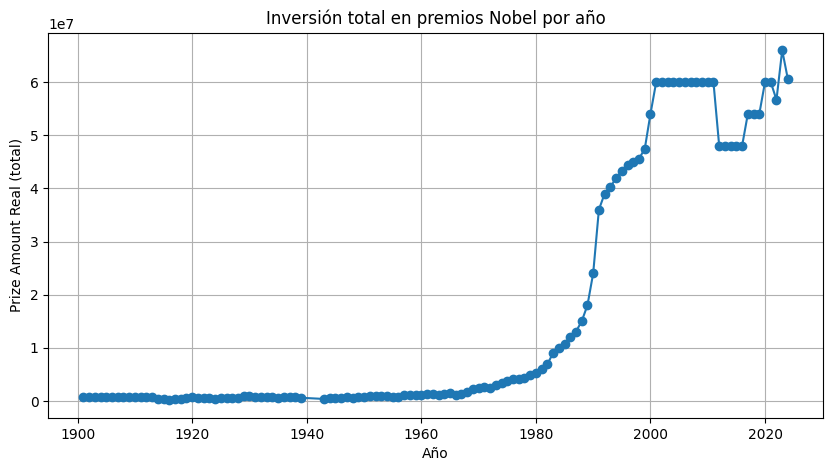

In [44]:
import matplotlib.pyplot as plt

investment_per_year = df.groupby('year')['prize_amount_real'].sum()
investment_per_year.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Inversión total en premios Nobel por año')
plt.ylabel('Prize Amount Real (total)')
plt.xlabel('Año')
plt.grid()
plt.show()

### Analysis

Total Nobel Prize spending has trended clearly upward over time, with a particularly steep climb starting in the 1980s.

In [45]:
award_counts = df.groupby(['laureate_id', 'full_name']).size().reset_index(name='num_premios')
top_repeat = award_counts[award_counts['num_premios'] > 2].sort_values('num_premios', ascending=False).head(5)

print("Top 5 laureados con más de dos premios:")
print(top_repeat)


Top 5 laureados con más de dos premios:
Empty DataFrame
Columns: [laureate_id, full_name, num_premios]
Index: []


### Analysis

No laureate has won more than two Nobel Prizes.

In [53]:

category_count = df['category'].value_counts()
top_category = category_count.head(1)
cat, n = top_category.index[0], top_category.iloc[0]
print(f"Categoría con más premios: {cat} ({n} premios)")


category_money = df.groupby('category')['prize_amount_real'].sum().sort_values(ascending=False)
cat_money, amount = category_money.head(1).index[0], category_money.head(1).iloc[0]
print(f"Categoría que más dinero ha entregado: {cat_money} ({amount:,.2f})")


Categoría con más premios: Physiology or Medicine (229 premios)
Categoría que más dinero ha entregado: Literature (340,157,420.00)
